In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Load dataset
df = pd.read_csv("../data/online_retail_customer_churn.csv")

print("Shape:", df.shape)
df.head()


Shape: (789, 7)


,recency,frequency,monetary,avg_spend_per_purchase,customer_value_score,recency_frequency_ratio,monetary_log
0,5,22,5892.58,256.199130,129636.76,0.217391,8.681619
1,13,77,9025.47,115.711154,694961.19,0.166667,9.107917
2,13,71,618.83,8.594861,43936.93,0.180556,6.429445
3,3,33,9110.30,267.950000,300639.90,0.088235,9.117271
4,15,43,5390.88,122.520000,231807.84,0.340909,8.592649


In [2]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 789 entries, 0 to 788
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   recency                  789 non-null    int64  
 1   frequency                789 non-null    int64  
 2   monetary                 789 non-null    float64
 3   avg_spend_per_purchase   789 non-null    float64
 4   customer_value_score     789 non-null    float64
 5   recency_frequency_ratio  789 non-null    float64
 6   monetary_log             789 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 43.3 KB


recency                    0
frequency                  0
monetary                   0
avg_spend_per_purchase     0
customer_value_score       0
recency_frequency_ratio    0
monetary_log               0
dtype: int64

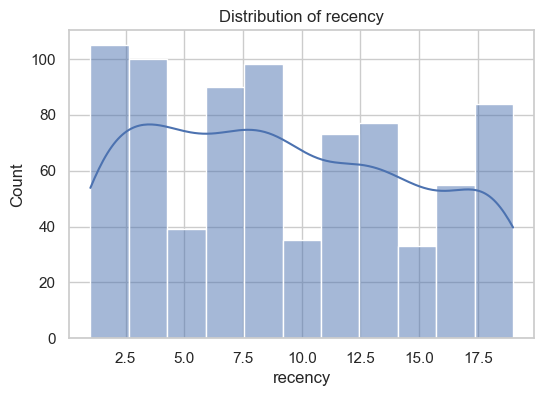

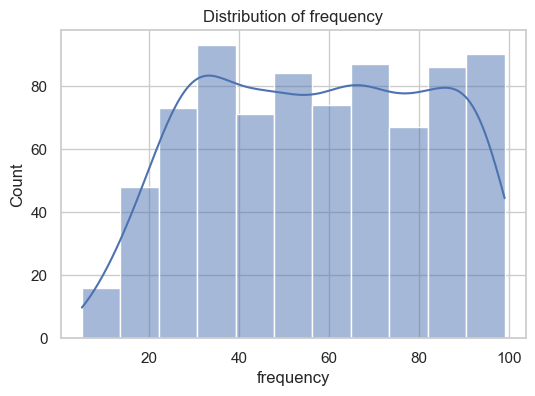

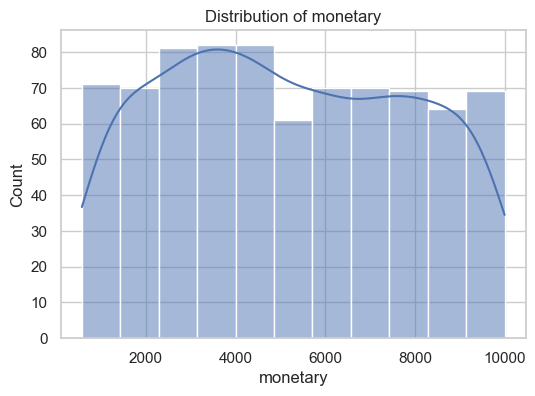

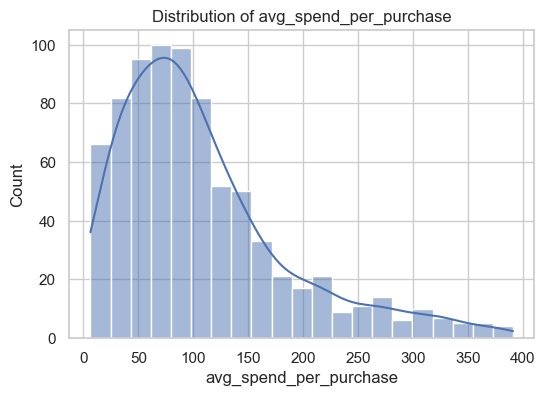

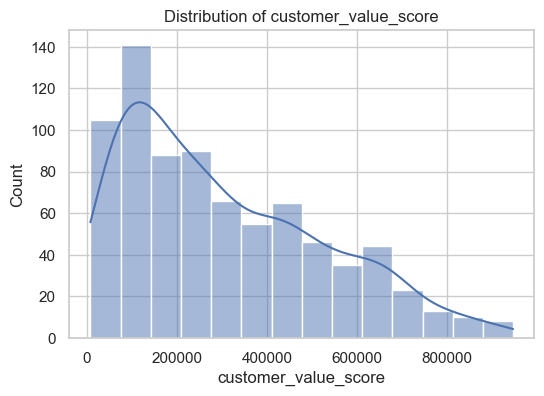

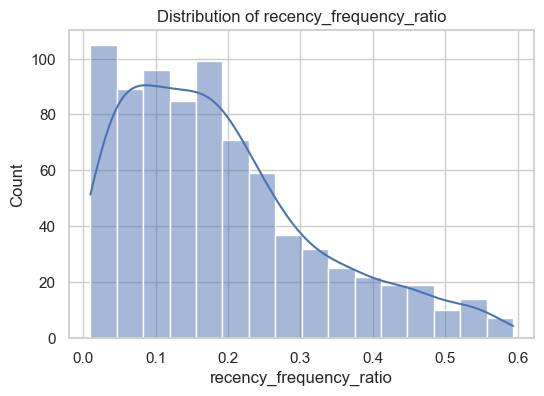

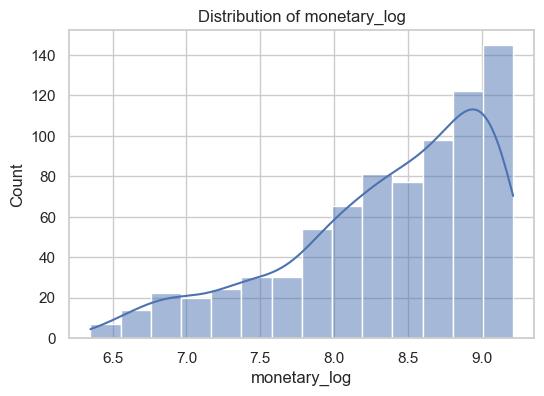

In [22]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [23]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()


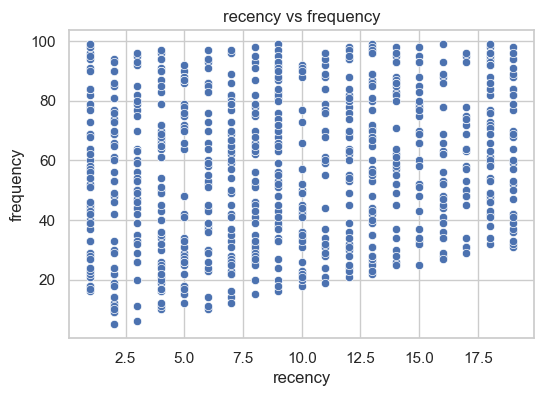

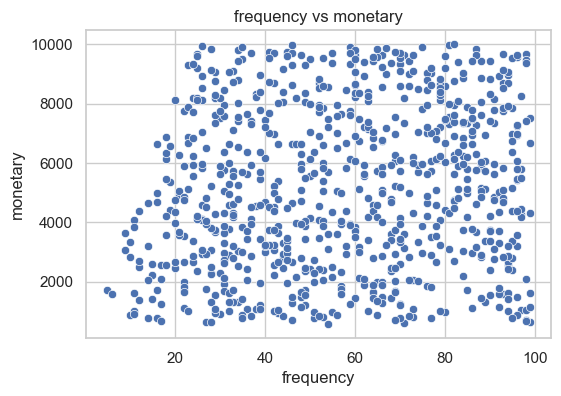

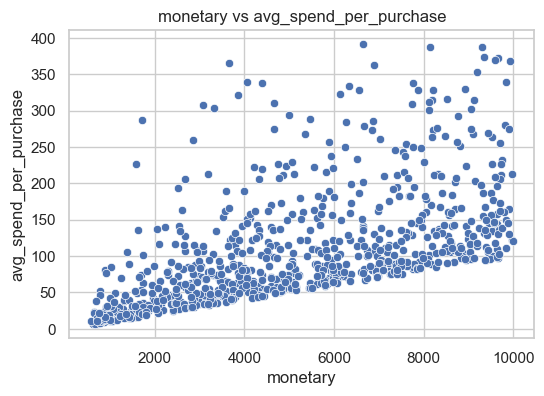

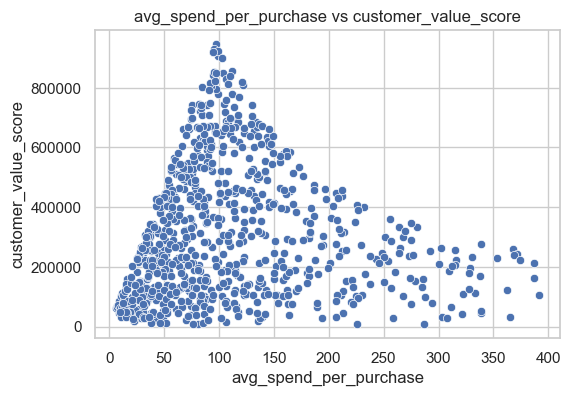

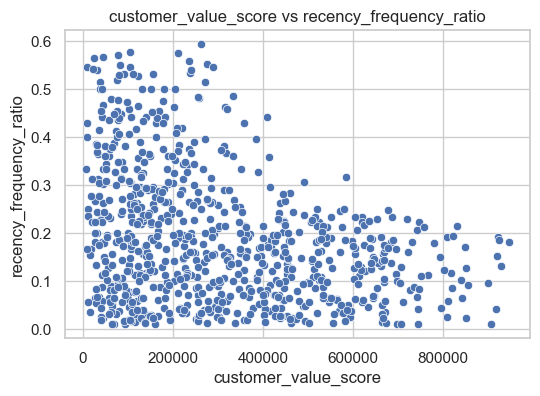

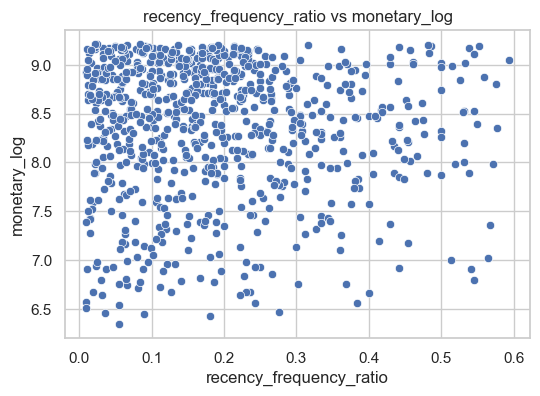

In [24]:
if len(num_cols) >= 2:
    for i in range(len(num_cols)-1):
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[num_cols[i]], y=df[num_cols[i+1]])
        plt.title(f"{num_cols[i]} vs {num_cols[i+1]}")
        plt.show()


In [25]:
for cat in cat_cols:
    for num in num_cols:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f"{num} by {cat}")
        plt.xticks(rotation=45)
        plt.show()


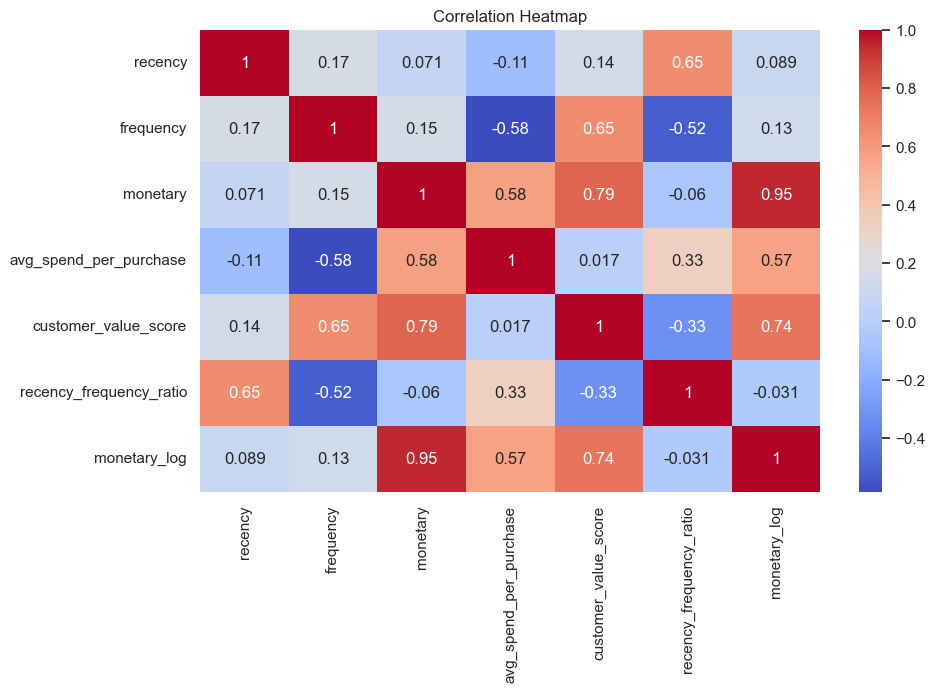

In [26]:
if len(num_cols) > 1:
    plt.figure(figsize=(10,6))
    corr = df[num_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()


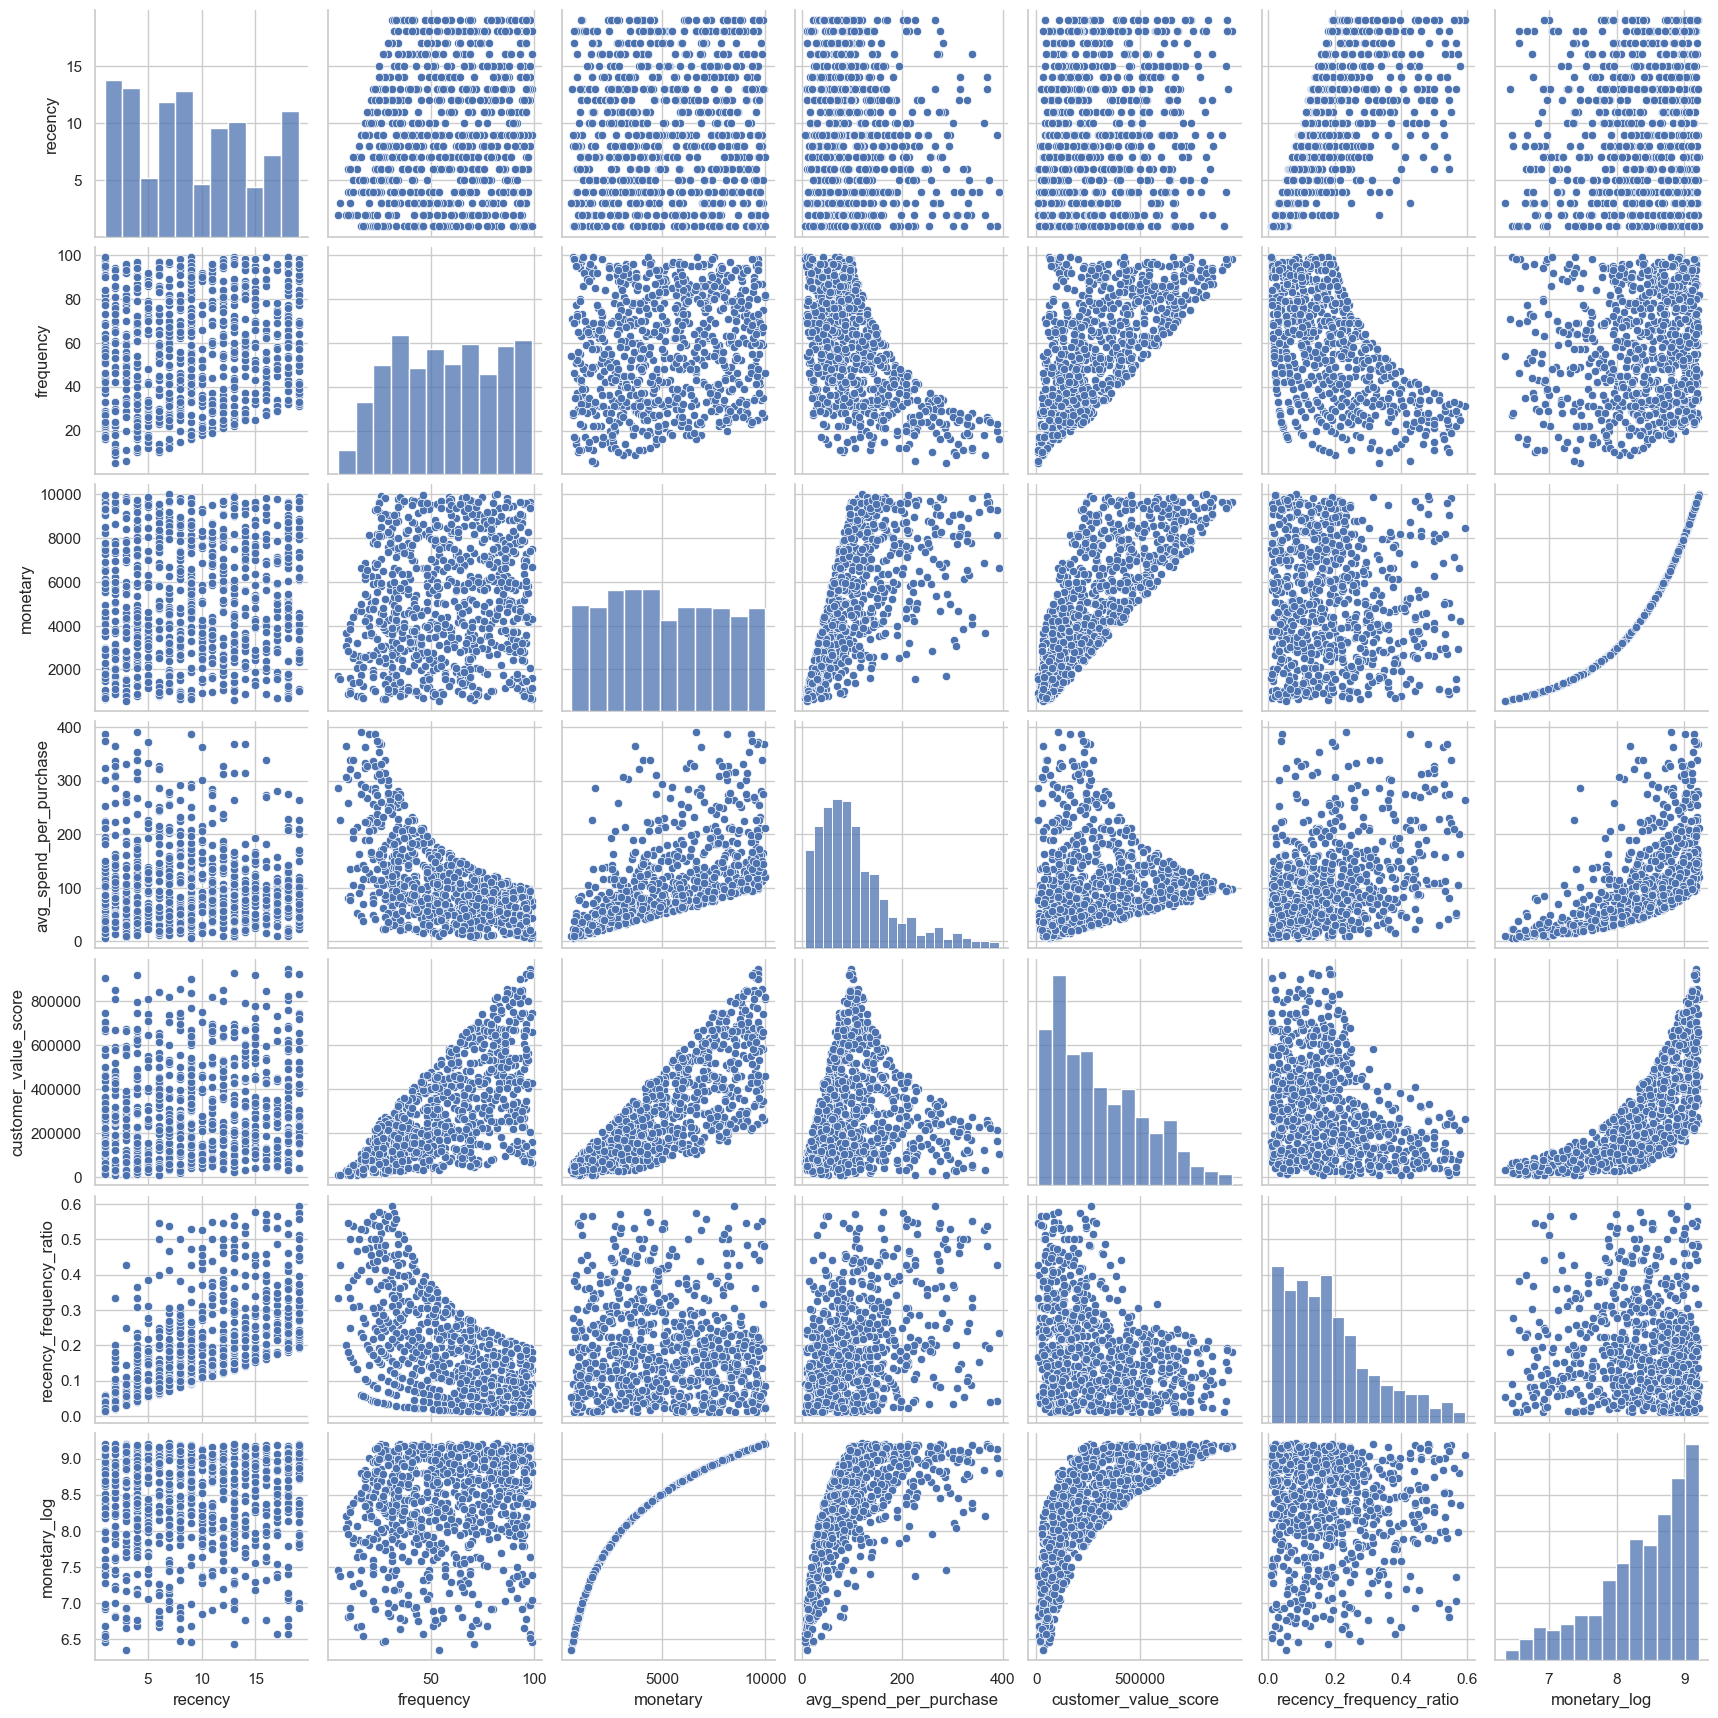

In [27]:
if len(num_cols) > 1:
    sns.pairplot(df[num_cols])
    plt.show()


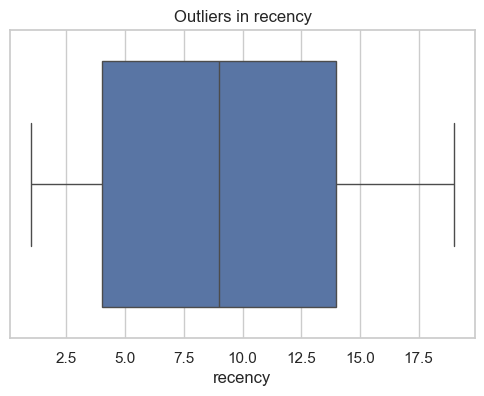

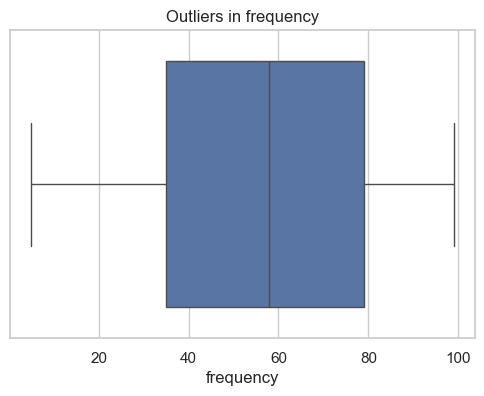

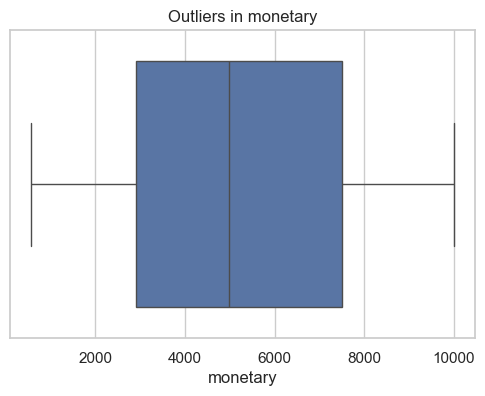

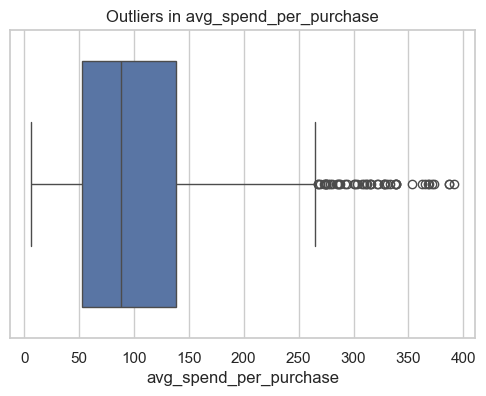

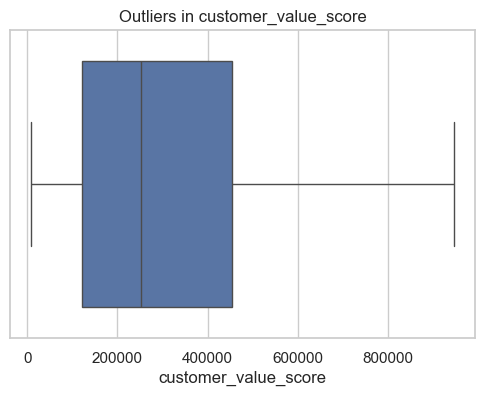

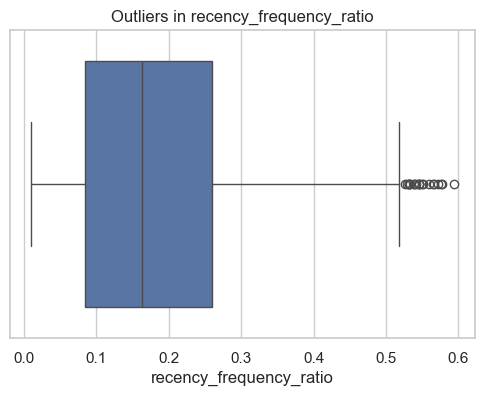

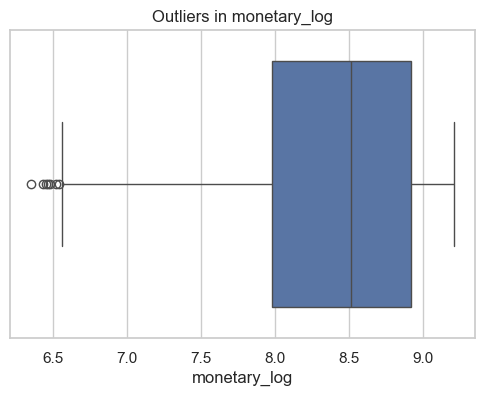

In [28]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()
